# EDA: Avito candidate retrieval

Цель анализа — понять устройство train/benchmark, проверить качество данных, длины текстов, повторы и полезность фильтров для Recall@50. Анализ читает Parquet проекциями, чтобы не держать распакованные длинные тексты одновременно.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import pyarrow.compute as pc
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
DATA = ROOT / 'dataset'
FIGURES = ROOT / 'reports' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(ROOT / 'src'))
sns.set_theme(style='whitegrid')

## 1. Размеры и схемы

In [2]:
rows = []
for path in sorted(DATA.glob('*.parquet')):
    pf = pq.ParquetFile(path)
    rows.append({'file': path.name, 'rows': pf.metadata.num_rows, 'columns': pf.metadata.num_columns, 'size_mb': path.stat().st_size / 2**20})
display(pd.DataFrame(rows).round(2))
for name in ('train.parquet', 'benchmark_queries.parquet', 'benchmark_items.parquet'):
    print(f'\n{name}:', pq.ParquetFile(DATA / name).schema_arrow.names)

,file,rows,columns,size_mb
0,benchmark_items.parquet,189212,14,186.61
1,benchmark_queries.parquet,2452,6,0.12
2,train.parquet,497673,19,467.53



train.parquet: ['search_query', 'search_location_id', 'search_is_delivery_search', 'search_infm_params_text', 'search_category', 'item_title_raw', 'item_rating_reviews_count', 'item_rating', 'item_price', 'item_microcat_id', 'item_longitude', 'item_location_id', 'item_latitude', 'item_is_phone_hidden', 'item_is_message_forbidden', 'item_infm_params_text', 'item_id', 'item_description_raw', 'item_category_id']

benchmark_queries.parquet: ['query_id', 'search_query', 'search_location_id', 'search_is_delivery_search', 'search_infm_params_text', 'search_category']

benchmark_items.parquet: ['item_title_raw', 'item_rating_reviews_count', 'item_rating', 'item_price', 'item_microcat_id', 'item_longitude', 'item_location_id', 'item_latitude', 'item_is_phone_hidden', 'item_is_message_forbidden', 'item_infm_params_text', 'item_id', 'item_description_raw', 'item_category_id']


## 2. Кардинальности, пропуски и повторы

In [3]:
query_cols = ['search_query','search_location_id','search_is_delivery_search','search_infm_params_text','search_category']
item_key_cols = ['item_id','item_category_id','item_microcat_id','item_location_id','item_rating','item_rating_reviews_count']
train_keys = pq.read_table(DATA/'train.parquet', columns=query_cols + item_key_cols).to_pandas()
bq = pq.read_table(DATA/'benchmark_queries.parquet').to_pandas()
bi_keys = pq.read_table(DATA/'benchmark_items.parquet', columns=item_key_cols).to_pandas()

summary = pd.DataFrame({
    'nulls': train_keys.isna().sum(),
    'null_rate': train_keys.isna().mean(),
    'n_unique': train_keys.nunique(dropna=True),
})
display(summary)
print('Уникальных полных запросов:', len(train_keys[query_cols].drop_duplicates()))
print('Уникальных текстов запросов:', train_keys.search_query.nunique())
print('Уникальных train item_id:', train_keys.item_id.nunique())
print('Повторных полных query-item пар:', train_keys.duplicated(query_cols + ['item_id']).sum())
print('Benchmark query_id уникальны:', bq.query_id.is_unique)
print('Benchmark item_id уникальны:', bi_keys.item_id.is_unique)
print('Benchmark query text встречался в train:', bq.search_query.isin(set(train_keys.search_query)).mean())
print('Benchmark items встречались в train:', bi_keys.item_id.isin(set(train_keys.item_id)).mean())

,nulls,null_rate,n_unique
search_query,0,0.000000,74529
search_location_id,0,0.000000,2782
search_is_delivery_search,0,0.000000,2
search_infm_params_text,0,0.000000,3724
search_category,0,0.000000,4
item_id,0,0.000000,344825
item_category_id,0,0.000000,8
item_microcat_id,0,0.000000,212
item_location_id,0,0.000000,2637
item_rating,28232,0.056728,8832


Уникальных полных запросов: 354463
Уникальных текстов запросов: 74529
Уникальных train item_id: 344825


Повторных полных query-item пар: 30619
Benchmark query_id уникальны: True
Benchmark item_id уникальны: True
Benchmark query text встречался в train: 0.3699021207177814


Benchmark items встречались в train: 0.09588186795763483


## 3. Сколько релевантных объявлений приходится на запрос

,unique_positive_items
count,354463.000000
mean,1.317638
std,1.611180
min,1.000000
50%,1.000000
75%,1.000000
90%,2.000000
95%,3.000000
99%,6.000000
max,278.000000


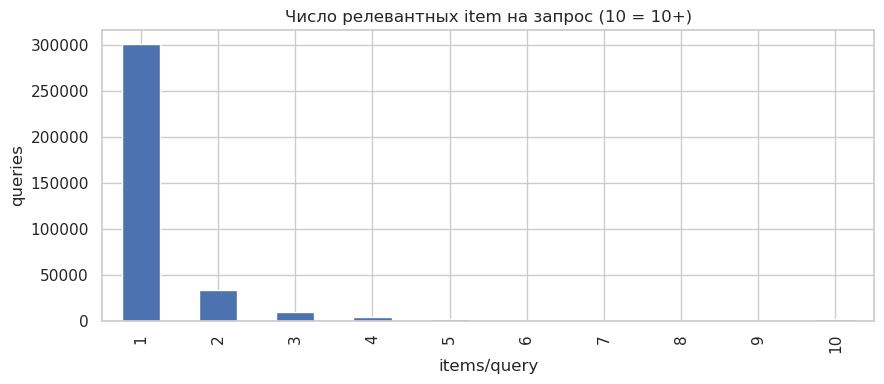

In [4]:
positives = train_keys.groupby(query_cols, dropna=False).item_id.nunique()
display(positives.describe(percentiles=[.5,.75,.9,.95,.99]).to_frame('unique_positive_items'))
ax = positives.clip(upper=10).value_counts().sort_index().plot.bar(figsize=(9,4))
ax.set(title='Число релевантных item на запрос (10 = 10+)', xlabel='items/query', ylabel='queries')
plt.tight_layout(); plt.savefig(FIGURES/'positives_per_query.png', dpi=140); plt.show()

## 4. Длины текстов и решение о chunking

,0.00,0.25,0.50,0.75,0.90,0.95,0.99,1.00
search_query,1.0,12.0,17.0,22.0,28.0,31.0,39.0,113.0
search_infm_params_text,0.0,0.0,28.0,54.0,72.0,97.0,106.0,1079.0
item_title_raw,1.0,24.0,34.0,44.0,48.0,50.0,56.0,100.0
item_infm_params_text,10.0,501.0,871.0,1362.0,2162.0,2965.0,6504.6,11899.0
item_description_raw,1.0,375.0,920.0,1793.0,2892.0,3876.0,5503.3,8494.0


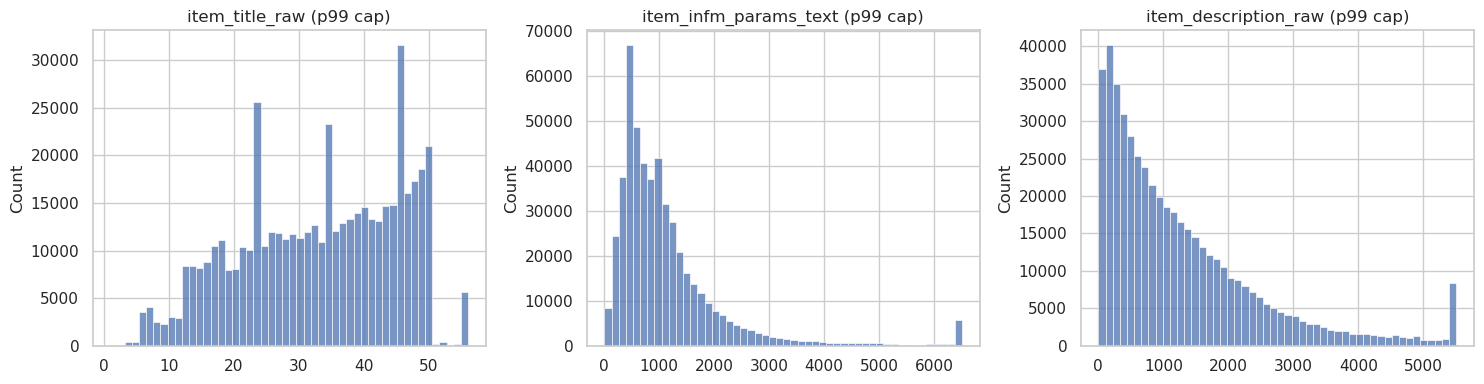

In [5]:
def parquet_text_lengths(path, columns):
    result = {c: [] for c in columns}
    for batch in pq.ParquetFile(path).iter_batches(columns=columns, batch_size=32768):
        for c in columns:
            values = pc.fill_null(batch.column(c), '')
            result[c].append(pc.utf8_length(values).to_numpy())
    return {c: np.concatenate(parts) for c, parts in result.items()}

train_text_cols = ['search_query','search_infm_params_text','item_title_raw','item_infm_params_text','item_description_raw']
lengths = parquet_text_lengths(DATA/'train.parquet', train_text_cols)
quantiles = [0,.25,.5,.75,.9,.95,.99,1]
length_table = pd.DataFrame({c: np.quantile(v, quantiles) for c,v in lengths.items()}, index=quantiles).T
display(length_table.round(1))

fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, c in zip(axes, ['item_title_raw','item_infm_params_text','item_description_raw']):
    cap = np.quantile(lengths[c], .99)
    sns.histplot(np.minimum(lengths[c], cap), bins=50, ax=ax)
    ax.set_title(f'{c} (p99 cap)')
plt.tight_layout(); plt.savefig(FIGURES/'text_lengths.png', dpi=140); plt.show()

## 5. Категория, локация, доставка и текстовые фильтры

In [6]:
category_match = train_keys.search_category.eq(train_keys.item_category_id)
location_match = train_keys.search_location_id.eq(train_keys.item_location_id)
print('Совпадение category:', category_match.mean())
print('Совпадение location:', location_match.mean())
display(pd.crosstab(train_keys.search_is_delivery_search, location_match, normalize='index').round(4))
display(pd.crosstab(train_keys.search_category, train_keys.item_category_id))
print('Пустой search_infm_params_text:', train_keys.search_infm_params_text.eq('').mean())
print('Запросы benchmark по категориям:')
display(bq.search_category.value_counts().to_frame('queries'))

Совпадение category: 0.9998935043693349
Совпадение location: 0.8310195650557696


col_0,False,True
search_is_delivery_search,,
0,0.169,0.831
1,0.500,0.500


item_category_id,10,19,27,28,40,81,112,114
search_category,,,,,,,,
0,0,0,0,0,0,0,0,34
10,0,0,0,0,0,0,0,2
81,0,0,0,0,0,0,0,2
114,1,2,4,2,2,2,2,497620


Пустой search_infm_params_text: 0.32953164025374093
Запросы benchmark по категориям:


,queries
search_category,
114,2230
0,222


## Выводы для retrieval

1. В train 354 463 уникальных полных запроса; медиана — один релевантный item, поэтому macro Recall@50 чувствителен к каждому промаху.
2. Объявления длинные: одного title недостаточно, а единый dense-вектор будет обрезать большую часть текста. Совместно режем параметры и описание на фиксированные passages с overlap, повторяем только короткий title и агрегируем passage → item.
3. Категория почти всегда совпадает (497 620 из 497 673), поэтому ненулевая `search_category` — безопасный hard filter. Значение 0 трактуется как отсутствие фильтра.
4. Локация совпадает примерно в 83.1%, поэтому hard filter по location уничтожил бы до 16.9% релевантных пар. Используем local и global retrieval-каналы и объединяем RRF.
5. `search_infm_params_text` непуст примерно в двух третях строк и должен входить в sparse/dense query; явные числовые ограничения можно применять как дополнительные каналы.
6. Только ~37% benchmark query-текстов и ~9.6% benchmark items встречались в train. Значит, exact-history полезна как дополнительный канал, но не заменяет контентный retrieval.